<a href="https://colab.research.google.com/github/joyangelai/Colabs/blob/main/Cohort2_Linux_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning/Cleansing/Wrangling

## Data cleaning will cover the following
1. Checking the columns and changing mispelled to correct names
2. checking missing values
3. checking for duplicates
4. checking for outliers

In [ ]:
#Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Loading the dataset and getting information

In [ ]:
#Reading the file: load diabetes.csv
data = pd.read_csv("diabetes.csv")

In [ ]:
#Checking top 5 columns
data.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
#checking the last 5 columns
data.tail()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
1004,191,454316,M,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y
1005,192,454316,M,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,Y
1006,193,454316,M,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,Y
1007,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1008,195,4543,f,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y


Observation: the data is uniform from top to bottom

In [ ]:
#checking the dataset shape
data.shape

(1009, 14)

In [ ]:
#checking the dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [ ]:
#checking the info 2
data.info(verbose= False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Columns: 14 entries, ID to CLASS
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [ ]:
#concise summary statistics
data.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1009.000000,1.009000e+03,1008.000000,1008.000000,1007.000000,1006.000000,1007.000000,1007.000000,1008.000000,1007.000000,1008.000000,1009.000000
mean,339.161546,2.717448e+05,53.620040,5.131094,68.973188,8.284155,4.863873,2.348769,1.204216,2.610119,1.850595,29.589911
std,239.738169,3.365681e+06,8.740975,2.931136,59.813297,2.533576,1.297326,1.397487,0.658158,1.116095,3.649859,4.946246
min,1.000000,1.230000e+02,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,127.000000,2.406500e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,296.000000,3.439900e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,548.000000,4.539000e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [ ]:
#Describe categorical features
data.describe(include= "O")

,Gender,CLASS
count,1009,1009
unique,3,5
top,M,Y
freq,570,840


In [ ]:
#Create a dataframe copy to be used in data cleaning using copy() method
data1 = data.copy(deep = True)
data1.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


In [ ]:
#check unique value for one variable
data['CLASS'].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [ ]:
data1.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [ ]:
# check for unique values in each column at once using for loop
for i in data1:
    coln_val = data1[i].unique()
    print(f" column name: {i},'\n' : {coln_val}, \n")



 column name: ID,'
' : [502 735 420 680 504 634 721 421 670 759 636 788  82 132 402 566 596 676
 729 742  64  97 126 390 458 470 494 564 696 106 138 315 650 678 699 703
 708 719 740 741 746 794 219 255 450 626 664 704 799 210 237 318 620 640
 668 701 174 276 345 482 630 789 348   7   9  10  42  47  71  72  83  88
  89  96  98  99 102 134 137 139 141 143 144 145 147 149 150 153 154 157
 161 165 166 171 180 181 182 186 190 197 435 472  85 710 429 702   4 189
 201 285 393 468 492 496 498 684 700 716 366 399 490 500 672 690 718 264
 464 466 686 688  16 705 709  19 123 476 682 706 754  68 342 712 715  12
  20  41  60  79  81 133 135 146 152 178  18  24 675  39 474 648  48 656
  57 658  69 662 714  87 231 505 654  61 127 228 674 744  58 108 198 357
 588 666 698 753 110 113 119 122 452 652 660 673 162 168 580 694 790 140
 375 426 453 534 612 692 717 725 777  67 109 351 552 685 750  31 129 173
 176 179 183 185 195 316 646 187 188 191 194 200 203 411 520 622 758 206
 600  76  86 209 212 215 218

### 2. Data Cleaning


#### 2.1. Checking the colunms and dealing with mispelled columns

In [ ]:
#check the colunms use columns attribute
data1.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [ ]:
#changing no_pation column, use rename method e.g df.rename(columns = {'old col name': 'new coln name'}, inplace = True )
data1.rename(columns = {'No_Pation': "Patient No"}, inplace=True)
data1.columns

Index(['ID', 'Patient No', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol',
       'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [ ]:
#Change columns name to lower case for unifromity# use .lower(), eg df.columns = df.columns.str.lower()
data1.columns = data1.columns.str.lower()

#confirming the changes
data1.columns

Index(['id', 'patient no', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol',
       'tg', 'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

In [ ]:
#Removing the white space if any, use .replace() e.g df.columns = df.columns.str.replace(' ', '')
data1.columns = data1.columns.str.replace(" ", "")
data1.columns

Index(['id', 'patientno', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol', 'tg',
       'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

In [ ]:
# removing whitespace before or after the variable name
data1["class"] =data1["class"].str.strip()

In [ ]:
#we can combine the 2 argument into one code
#df1.columns = df1.columns.str.lower().replace(' ', '_')

In [ ]:
#Drop unnessary columns
#a. del df['col name'] # you can also used drop method: df.drop(columns = 'col_name', axis=1, inplace=True)

#when dropping one variable
#del data1["id"]

#using drop method
data1.drop(columns = "id", axis =1, inplace= True)

data1.columns

Index(['patientno', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol', 'tg',
       'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

### 2.2 Checking the missing values and dealing with them

In [ ]:
#check the missing values, you can either use isna or isnull()
data1.isna().sum()  # you can also use isnull()  # check on how you can convert these null values into percantage

patientno    0
gender       0
age          1
urea         1
cr           2
hba1c        3
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#getting the null value total
data1.isna().sum().sum()

15

In [ ]:
#checking if we have any null values in the dataframe
data1.isna().sum().any()

True

In [ ]:
#a. imputing "hba1c " variable using the mean
#Get the mean  e.g mean_values = df.coln.mean()
hb_mean = data1['hba1c'].mean()

#fill up the missing value, use fillna e.g df['col'].fillna(mean_values, inplace=True)
data1['hba1c'].fillna(data1['hba1c'].mean(),)

0        4.900000
1        4.900000
2        4.900000
3        4.900000
4        4.900000
          ...    
1004     6.800000
1005     8.284155
1006     6.700000
1007     9.300000
1008    13.900000
Name: hba1c, Length: 1009, dtype: float64

In [ ]:
data1.isna().sum()

patientno    0
gender       0
age          1
urea         1
cr           2
hba1c        3
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#b another way of doing the same thing as a bove e.g df['col'].fillna(df['col'].mean(), inplace=True)data1["age"].fillna(data1["age"].mean())

In [ ]:
# imputing null values using another method
age_mean = data1["age"].mean()
data1.fillna({"age": age_mean}, inplace= True)
data1.isnull().sum()

patientno    0
gender       0
age          0
urea         1
cr           2
hba1c        3
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#d. how to impute using the mode
#coln_mode = df.colname.mode()[0]
mode_gender = data1["class"].mode()[0]
mode_gender

# impute with the mode
#df['col'].fillna(col_mode, inplace=True) # use bfill for backword fill, and ffill for forward fill

'Y'

Observations:

The mode of a dataset can have multiple values. When we call `mode()` on a Pandas dataframe, it returns a Series object containing all the modal values. To access the first modal value, we use the `[0]` index.

For example, if the mode of the `gender` column in the `df1` dataframe is both `'Female'` and `'Male'`, then `df1.gender.mode()` will return a Series object containing both values. To access the first modal value, which is `'Female'`, we use `df1.gender.mode()[0]`.

Using `[0]` ensures that we are only using the first modal value for imputation, rather than all the modal values. This is important because using multiple values for imputation can introduce bias into the data.

In [ ]:
data1.isna().sum()

patientno    0
gender       0
age          0
urea         0
cr           0
hba1c        0
chol         0
tg           0
hdl          0
ldl          0
vldl         0
bmi          0
class        0
dtype: int64

In [ ]:
#e. Fill missing values with specific values e.g 0
#df['col'].fillna(0, inplace=True)
data1["chol"].fillna(0, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12308\1136418754.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1["chol"].fillna(0, inplace = True)


In [ ]:
#
data1.fillna({: value}

In [ ]:
#f.Fill missing values in the categorical columns with specific values
#df['col'].fillna('unknown', inplace=True)


In [ ]:
#dropping the missing values# we drop when we just have few missing values using dropna
data1.dropna(inplace = True)
data1.isna().sum()

patientno    0
gender       0
age          0
urea         0
cr           0
hba1c        0
chol         0
tg           0
hdl          0
ldl          0
vldl         0
bmi          0
class        0
dtype: int64

In [ ]:
#check the null values using isna()


In [ ]:
#Replacing values in the class column
#df.groupby('class')['class'].count()
data1.groupby("gender")[['gender']].count()

,gender
gender,
F,431
M,563
f,2


In [ ]:
#check unique in class variable
data1["class"].unique()

array(['N', 'P', 'Y'], dtype=object)

In [ ]:
#replace values in class, and gender coln df['coln'] = df['coln'].str.replace('N ','N')
data["class"] = data1["class"].str.replace("N ", "N")

#fix y value from class column
data1["class"] = data["class"].str.replace("Y ", "Y")

data1["class"].unique()


array(['N', 'P', 'Y'], dtype=object)

In [ ]:
#how to use strip
data_strip = data[["CLASS"]]
data_strip['CLASS'].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [ ]:
data_strip["CLASS"] = data_strip["CLASS"].str.strip()
data_strip['CLASS'].unique()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12308\3497320875.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_strip["CLASS"] = data_strip["CLASS"].str.strip()


array(['N', 'P', 'Y'], dtype=object)

In [ ]:
#check count again  df.groupby('class')['class'].count()

In [ ]:
#do the same for gender


In [ ]:
#replace values in gender


### 2.3 Checking for duplicate


In [ ]:
#check duplicates use duplcated()
data1.duplicated().sum()

3

In [ ]:
#drop the duplicates
data1.drop_duplicates(inplace=True)

#checking on whether duplicates were dropped
data1.duplicated().sum()

0

### 2.4 Checking for outliers


<Axes: >

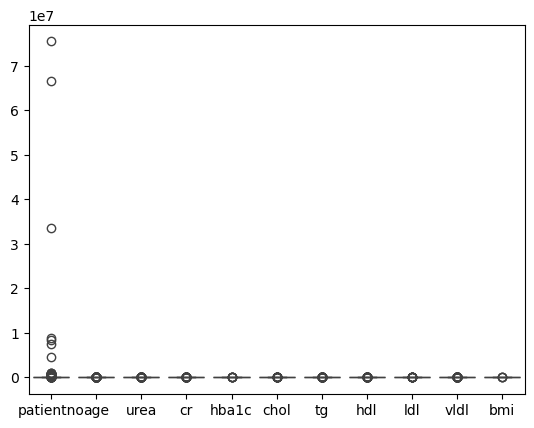

In [ ]:
#checking for outlier, use boxplot on cr coln
sns.boxplot(data1)

<Axes: ylabel='cr'>

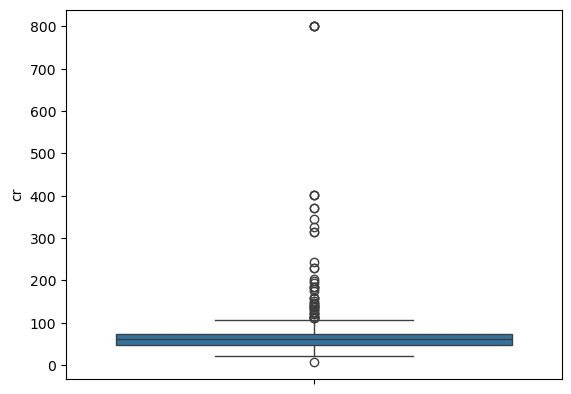

In [ ]:
#check outlier for cr
sns.boxplot(y= data1["cr"])

In [ ]:
#concise summary
data1.describe().T

,count,mean,std,min,25%,50%,75%,max
patientno,993.0,272160.000000,3.392610e+06,123.0,24063.00,34393.0,45381.0,75435657.00
age,993.0,53.569990,8.761018e+00,25.0,51.00,55.0,59.0,79.00
urea,993.0,5.130053,2.947068e+00,0.5,3.66,4.6,5.7,38.90
cr,993.0,68.794562,6.010255e+01,6.0,48.00,60.0,73.0,800.00
hba1c,993.0,8.280020,2.537753e+00,0.9,6.50,8.0,10.2,16.00
chol,993.0,4.849970,1.318148e+00,0.0,4.00,4.8,5.6,10.30
tg,993.0,2.344723,1.399671e+00,0.3,1.50,2.0,2.9,13.80
hdl,993.0,1.206294,6.623845e-01,0.2,0.90,1.1,1.3,9.90
ldl,993.0,2.610564,1.118117e+00,0.3,1.80,2.5,3.3,9.90
vldl,993.0,1.860926,3.675612e+00,0.1,0.70,0.9,1.5,35.00


In [ ]:
#Remove the outlier using the maximum quantile in cr column

#a. Get the max interquantile at 0.995
max_ir = data1["cr"].quantile(0.995)
max_ir

401.0

In [ ]:
#check the values under outliers
data1[data1["cr"] > max_ir]

,patientno,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
273,34325,M,58.0,20.8,800.0,9.1,6.6,2.9,1.1,4.3,1.3,33.0,Y
283,24060,M,58.0,20.8,800.0,9.1,6.6,2.9,1.1,4.3,1.3,33.0,Y
846,34325,M,56.0,20.8,800.0,9.0,4.6,2.0,1.2,2.5,0.9,35.0,Y
860,51623,M,60.0,20.8,800.0,9.0,2.3,1.1,0.9,0.9,0.5,33.0,Y


In [ ]:
#Remove the outlier by assigning the value to a new DataFrame
dfnew = data1[data1["cr"] < max_ir]

<Axes: ylabel='cr'>

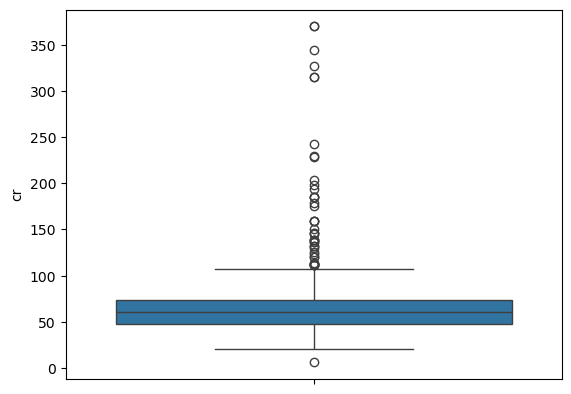

In [ ]:
#confirm removal of outlier
sns.boxplot(y= dfnew["cr"])

The outlier has been removed

<Axes: ylabel='cr'>

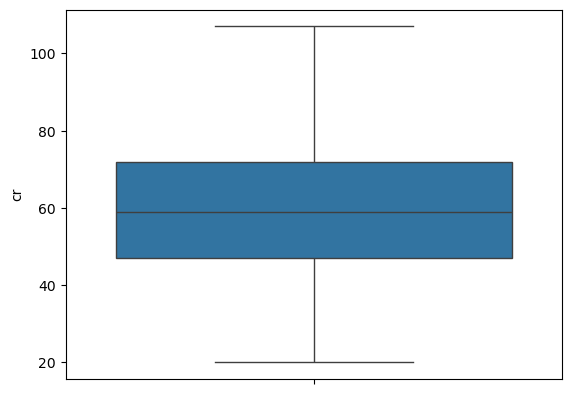

In [ ]:
#b. similary we can use iqr to remove the outliers

# Calculate the interquartile range (IQR)
q1 = data1['cr'].quantile(0.25)
q3 = data1['cr'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Filter the data to remove outliers
df2 = data1[(data1['cr'] >= lower_bound) & (data1['cr'] <= upper_bound)]
df2

# Check the boxplot again
sns.boxplot(y= df2["cr"])